# **1DCNN модель, для задачм предсказания ECM параметров**.

## Загрузка данных

Библиотеки

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import copy
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from tqdm import tqdm
import os
import random

Распаковка данных

In [162]:
!python -m zipfile -e /content/param_ecm-new_data_param.zip /content/

### Загрузка датасетов.

In [163]:
target_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_main.csv'

feature_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_pls_tables'

## Обработка Датасетов

#### Обработка X (features)

In [164]:
X_data_dict = {}

for filename in os.listdir(feature_path):
  if filename.endswith('.csv'):
    full_path = os.path.join(feature_path, filename)

    X_data_dict[filename] = pd.read_csv(full_path)[['Time', 'I', 'E']]

filenames_list = list(X_data_dict.keys())

print(f"Всего файлов загружено: {len(filenames_list)}")
print(f"Первый файл: {filenames_list[0]}")

Всего файлов загружено: 72
Первый файл: soc55_1Cdch_9sec.csv


#### Обработка y (target)

In [165]:
y_data = pd.read_csv(target_path)
y_data.head(3)

,I,R0,R1,R2,Udrop,Ufin,Uinit,cellcap,dSoC,dltQ,name,nominal_soc,tau1,tau2,tau_pls,table_file
0,-1.699624,0.035922,0.021680,0.002503,0.0576,3.6642,3.6656,3.36,-0.001265,-15.296620,soc45_05Cdch_9sec,0.45,49.006981,100,9,soc45_05Cdch_9sec.csv
1,-1.699615,0.038267,0.026703,0.004275,0.0596,3.6627,3.6653,3.36,-0.002529,-30.593065,soc45_05Cdch_18sec,0.45,71.978738,100,18,soc45_05Cdch_18sec.csv
2,-1.699670,0.039573,0.029765,0.006881,0.0597,3.6611,3.6656,3.36,-0.005059,-61.188125,soc45_05Cdch_36sec,0.45,98.442333,100,36,soc45_05Cdch_36sec.csv


In [166]:
first_filename = filenames_list[0]
first_dataframe = X_data_dict[first_filename]

first_dataframe.head(3)

,Time,I,E
0,0.0,-3.3978,3.6438
1,0.1,-3.3978,3.6438
2,0.2,-3.3981,3.6429


### Преобразуем данные, оставим, только R0, R1, R2, tau1, tau2, table_file, tau_pls.

In [167]:
y_data_valid = y_data.copy()

y_data_valid = y_data_valid[['R0', 'R1', 'R2', 'tau1', 'tau2', 'table_file', 'tau_pls', 'Ufin', 'Uinit']]
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2,table_file,tau_pls,Ufin,Uinit
0,0.035922,0.021680,0.002503,49.006981,100,soc45_05Cdch_9sec.csv,9,3.6642,3.6656
1,0.038267,0.026703,0.004275,71.978738,100,soc45_05Cdch_18sec.csv,18,3.6627,3.6653
2,0.039573,0.029765,0.006881,98.442333,100,soc45_05Cdch_36sec.csv,36,3.6611,3.6656


In [168]:
y_data_valid = y_data_valid.set_index('table_file')
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2,tau_pls,Ufin,Uinit
table_file,,,,,,,,
soc45_05Cdch_9sec.csv,0.035922,0.021680,0.002503,49.006981,100,9,3.6642,3.6656
soc45_05Cdch_18sec.csv,0.038267,0.026703,0.004275,71.978738,100,18,3.6627,3.6653
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,98.442333,100,36,3.6611,3.6656


#### Проверю доступность строк.

In [169]:
y_data_valid.loc['soc45_05Cdch_9sec.csv']

,soc45_05Cdch_9sec.csv
R0,0.035922
R1,0.021680
R2,0.002503
tau1,49.006981
tau2,100.000000
tau_pls,9.000000
Ufin,3.664200
Uinit,3.665600


#### Преобразуем tau в C по формуле C = tau / R

In [170]:
y_data_ECM = y_data_valid.copy()
y_data_ECM['C1'] = y_data_ECM['tau1'] / y_data_ECM['R1']
y_data_ECM['C2'] = y_data_ECM['tau2'] / y_data_ECM['R2']
y_data_ECM = y_data_ECM.drop(columns = ['tau1', 'tau2'])
y_data_ECM

,R0,R1,R2,tau_pls,Ufin,Uinit,C1,C2
table_file,,,,,,,,
soc45_05Cdch_9sec.csv,0.035922,0.021680,0.002503,9,3.6642,3.6656,2260.448803,39953.664553
soc45_05Cdch_18sec.csv,0.038267,0.026703,0.004275,18,3.6627,3.6653,2695.552979,23393.126693
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,36,3.6611,3.6656,3307.338185,14533.132864
soc45_05Cdch_72sec.csv,0.040419,0.026845,0.009549,72,3.6576,3.6661,4039.711416,10472.793336
soc45_05Cdch_144sec.csv,0.041387,0.024470,0.012494,144,3.6510,3.6666,5041.127631,8003.795124
...,...,...,...,...,...,...,...,...
soc55_1Cchr_36sec.csv,0.037162,0.015144,0.004966,36,3.7599,3.7462,2894.353334,20136.191961
soc55_1Cchr_72sec.csv,0.037716,0.014151,0.006390,72,3.7600,3.7350,3256.514024,15650.545530
soc55_2Cchr_9sec.csv,0.035879,0.016251,0.002251,9,3.7600,3.7526,2243.239787,44432.795075


In [171]:
common_keys = sorted(set(X_data_dict.keys()) & set(y_data_ECM.index))

X_df = {
    key: [
        float(y_data_ECM.loc[key, 'tau_pls']),
        X_data_dict[key].iloc[:3000][['Time', 'I', 'E']].copy()
    ]
    for key in common_keys
}

print(f"Общих ключей между X и y: {len(common_keys)}")
X_df['soc45_05Cdch_9sec.csv']

Общих ключей между X и y: 72


[9.0,
        Time       I       E
 0       0.0 -1.6987  3.6080
 1       0.1 -1.6987  3.6080
 2       0.2 -1.6988  3.6077
 3       0.3 -1.6991  3.6074
 4       0.4 -1.6992  3.6068
 ...     ...     ...     ...
 2995  299.4  0.0000  3.6640
 2996  299.5  0.0000  3.6640
 2997  299.6  0.0000  3.6640
 2998  299.7  0.0000  3.6640
 2999  299.8  0.0000  3.6640
 
 [3000 rows x 3 columns]]

In [172]:
y_data_ECM.loc['soc45_05Cdch_9sec.csv']

,soc45_05Cdch_9sec.csv
R0,0.035922
R1,0.021680
R2,0.002503
tau_pls,9.000000
Ufin,3.664200
Uinit,3.665600
C1,2260.448803
C2,39953.664553


## Разобьем данные на train и validation

In [173]:
csv_names = sorted(X_df.keys())

tau_for_split = pd.Series(
    {key: X_df[key][0] for key in csv_names},
    name='tau_pls'
)

tau_counts = tau_for_split.value_counts()
can_stratify = tau_counts.min() >= 2

In [174]:
train_keys, val_keys = train_test_split(
    csv_names,
    test_size=0.3,
    random_state=42,
    stratify=tau_for_split.loc[csv_names] if can_stratify else None
)

train_keys = sorted(train_keys)
val_keys = sorted(val_keys)

In [175]:
X_train_data = {key: X_df[key] for key in train_keys}
X_val_data = {key: X_df[key] for key in val_keys}

In [176]:
print(f"Всего профилей: {len(csv_names)}")
print(f"Train: {len(X_train_data)}")
print(f"Val: {len(X_val_data)}")
print("\nРаспределение tau_pls в train:")
print(pd.Series({k: X_train_data[k][0] for k in train_keys}).value_counts().sort_index())
print("\nРаспределение tau_pls в val:")
print(pd.Series({k: X_val_data[k][0] for k in val_keys}).value_counts().sort_index())

Всего профилей: 72
Train: 50
Val: 22

Распределение tau_pls в train:
9.0      17
18.0     13
36.0      8
72.0      8
144.0     4
Name: count, dtype: int64

Распределение tau_pls в val:
9.0      7
18.0     5
36.0     4
72.0     4
144.0    2
Name: count, dtype: int64


In [177]:
print(train_keys)

['soc45_05Cchr_144sec.csv', 'soc45_05Cchr_36sec.csv', 'soc45_05Cchr_72sec.csv', 'soc45_05Cchr_9sec.csv', 'soc45_05Cdch_18sec.csv', 'soc45_05Cdch_9sec.csv', 'soc45_1Cchr_18sec.csv', 'soc45_1Cchr_36sec.csv', 'soc45_1Cchr_72sec.csv', 'soc45_1Cchr_9sec.csv', 'soc45_1Cdch_18sec.csv', 'soc45_1Cdch_9sec.csv', 'soc45_2Cchr_18sec.csv', 'soc45_2Cchr_9sec.csv', 'soc45_2Cdch_18sec.csv', 'soc45_2Cdch_9sec.csv', 'soc50_05Cchr_144sec.csv', 'soc50_05Cchr_18sec.csv', 'soc50_05Cchr_36sec.csv', 'soc50_05Cchr_9sec.csv', 'soc50_05Cdch_18sec.csv', 'soc50_05Cdch_36sec.csv', 'soc50_05Cdch_72sec.csv', 'soc50_05Cdch_9sec.csv', 'soc50_1Cdch_18sec.csv', 'soc50_1Cdch_36sec.csv', 'soc50_1Cdch_72sec.csv', 'soc50_1Cdch_9sec.csv', 'soc50_2Cchr_9sec.csv', 'soc50_2Cdch_9sec.csv', 'soc50_3Cdch_9sec.csv', 'soc55_05Cchr_144sec.csv', 'soc55_05Cchr_18sec.csv', 'soc55_05Cchr_72sec.csv', 'soc55_05Cchr_9sec.csv', 'soc55_05Cdch_144sec.csv', 'soc55_05Cdch_18sec.csv', 'soc55_05Cdch_36sec.csv', 'soc55_05Cdch_72sec.csv', 'soc55_05Cd

In [178]:
y_train_full = y_data_ECM.loc[train_keys].copy()
y_val_full = y_data_ECM.loc[val_keys].copy()

target_cols = ['R0', 'R1', 'R2', 'C1', 'C2', 'Ufin']

y_train_data = y_train_full[target_cols].copy()
y_val = y_val_full[['R0', 'R1', 'R2', 'C1', 'C2', 'Ufin']].copy()

print("y_train_full:", y_train_full.shape)
print("y_val_full:", y_val_full.shape)
print("y_train:", y_train_data.shape)
print("y_val:", y_val.shape)

y_train_full: (50, 8)
y_val_full: (22, 8)
y_train: (50, 6)
y_val: (22, 6)


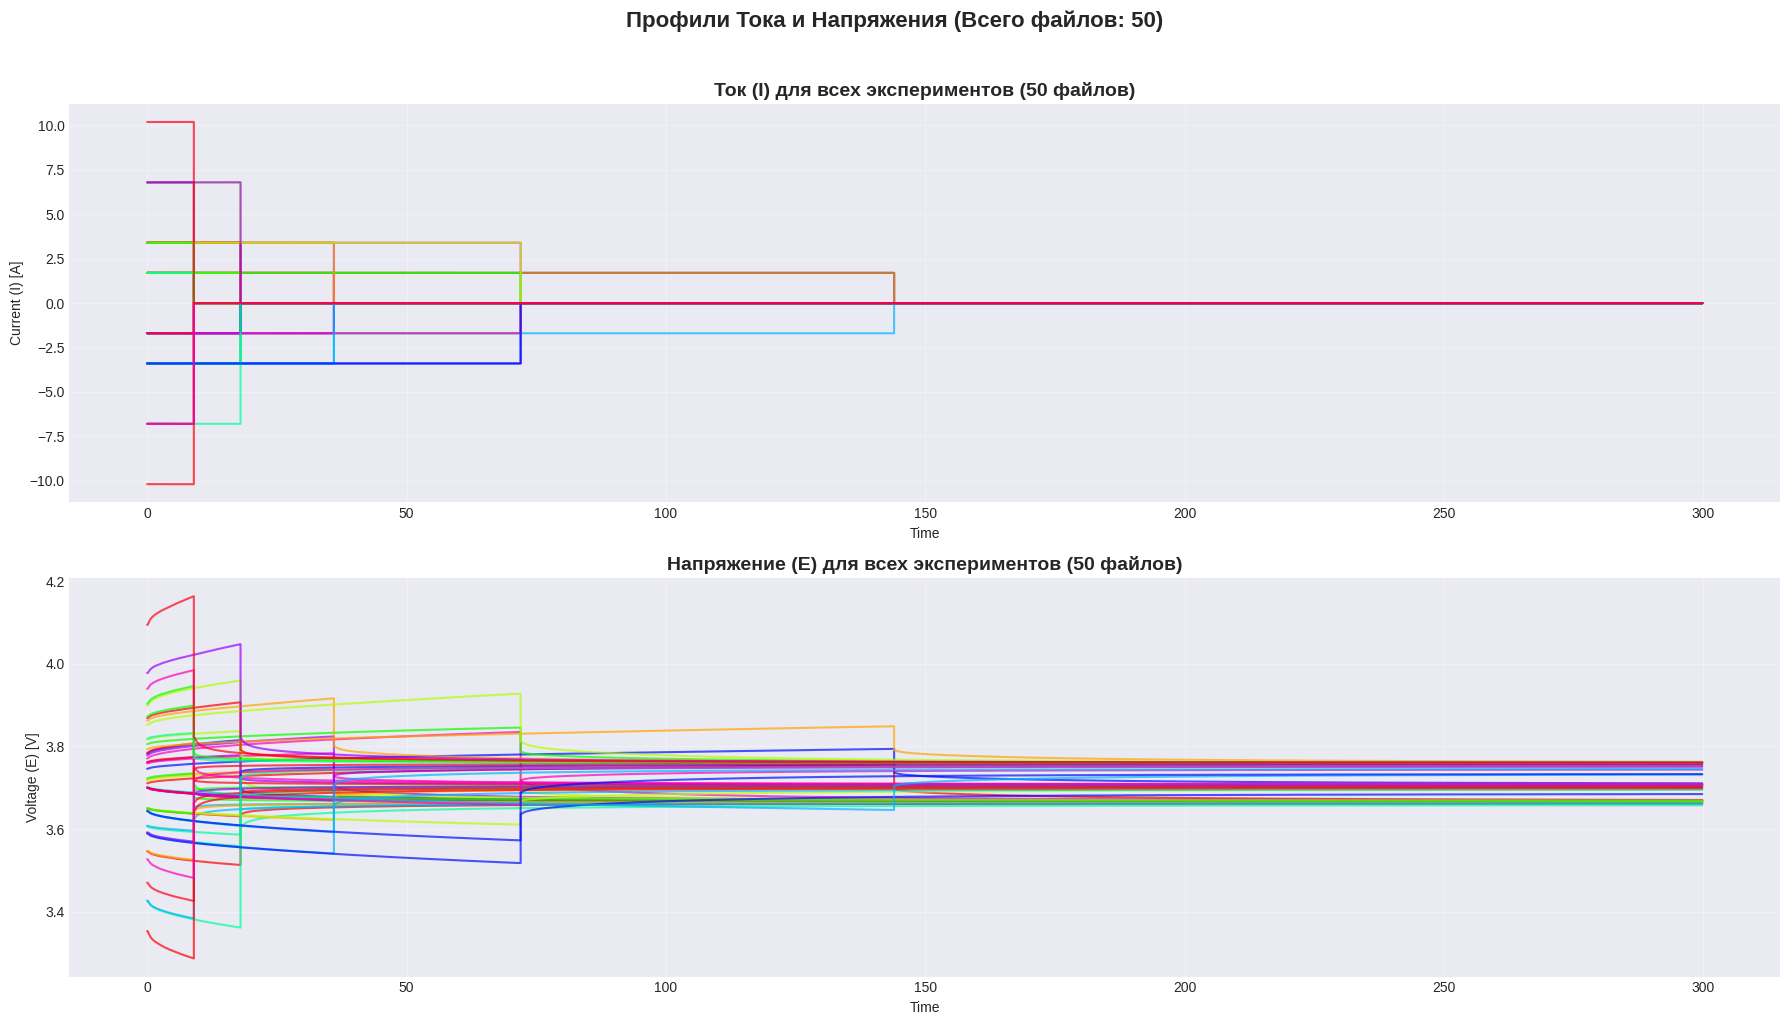

In [179]:
filenames_list = sorted([f for f in X_train_data.keys() if f.endswith('.csv')])
files_to_plot = filenames_list

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
ax_I = axes[0]
ax_E = axes[1]

colors = plt.cm.hsv(np.linspace(0, 1, 10))

for i, filename in enumerate(files_to_plot):
    if len(X_train_data[filename]) < 2:
        continue

    df = X_train_data[filename][1]

    if 'Time' not in df.columns or 'I' not in df.columns or 'E' not in df.columns:
        continue

    df_plot = df
    color = colors[i % len(colors)]

    ax_I.plot(df_plot['Time'], df_plot['I'],
              color=color, linewidth=1.5, alpha=0.7,
              label=f'{filename}')

    ax_E.plot(df_plot['Time'], df_plot['E'],
              color=color, linewidth=1.5, alpha=0.7,
              label=f'{filename}', linestyle='-')

ax_I.set_title(f'Ток (I) для всех экспериментов ({len(files_to_plot)} файлов)', fontsize=14, fontweight='bold')
ax_I.set_xlabel('Time')
ax_I.set_ylabel('Current (I) [A]')
ax_I.grid(True, alpha=0.3)

ax_E.set_title(f'Напряжение (E) для всех экспериментов ({len(files_to_plot)} файлов)', fontsize=14, fontweight='bold')
ax_E.set_xlabel('Time')
ax_E.set_ylabel('Voltage (E) [V]')
ax_E.grid(True, alpha=0.3)

if len(files_to_plot) <= 15:
    ax_I.legend(loc='upper right', fontsize=8)
    ax_E.legend(loc='upper right', fontsize=8)

plt.suptitle(f'Профили Тока и Напряжения (Всего файлов: {len(files_to_plot)})', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Данные и их статистики.

#### Features

In [180]:
X_train_statistics = []
X_train_time_pls = []

for i, key in enumerate(train_keys):
  X_train_statistics.append(X_train_data[key][1].values)
  X_train_time_pls.append(X_train_data[key][0])

In [181]:
stats_list = []

for i, data_item in enumerate(X_train_statistics):

    arr = np.array(data_item)


    # Извлекаем колонки по индексам: 0 - Время, 1 - Ток, 2 - Напряжение
    time_series = arr[:, 0]
    current_series = arr[:, 1]
    voltage_series = arr[:, 2]
    actual_length = len(time_series)

    def get_stats(series):
        return {
            'min': np.min(series),
            'max': np.max(series),
            'mean': np.mean(series),
            'std': np.std(series),
        }

    stats_v = get_stats(voltage_series)
    stats_c = get_stats(current_series)

    stats = {
        'key': train_keys[i],
        'tau_pls': X_train_time_pls[i],
        'length': actual_length,

        # Напряжение (Voltage)
        'volt_min': stats_v['min'],
        'volt_max': stats_v['max'],
        'volt_mean': stats_v['mean'],
        'volt_std': stats_v['std'],

        # Ток (Current)
        'curr_min': stats_c['min'],
        'curr_max': stats_c['max'],
        'curr_mean': stats_c['mean'],
        'curr_std': stats_c['std'],
    }

    stats_list.append(stats)

df_stats = pd.DataFrame(stats_list)

print("Статистика по тренировочным последовательностям:")
df_stats

Статистика по тренировочным последовательностям:


,key,tau_pls,length,volt_min,volt_max,volt_mean,volt_std,curr_min,curr_max,curr_mean,curr_std
0,soc45_05Cchr_144sec.csv,144.0,3000,3.6705,3.7563,3.707622,0.034423,0.0000,1.6999,0.816483,0.849255
1,soc45_05Cchr_36sec.csv,36.0,3000,3.6671,3.7461,3.677795,0.022348,0.0000,1.6999,0.204547,0.553043
2,soc45_05Cchr_72sec.csv,72.0,3000,3.6683,3.7516,3.688406,0.029990,0.0000,1.6999,0.408525,0.726313
3,soc45_05Cchr_9sec.csv,9.0,3000,3.6657,3.7349,3.668629,0.011038,0.0000,1.6999,0.051556,0.291496
4,soc45_05Cdch_18sec.csv,18.0,3000,3.5866,3.6618,3.656005,0.015995,-1.6997,0.0000,-0.102543,0.404682
5,soc45_05Cdch_9sec.csv,9.0,3000,3.5961,3.6640,3.661099,0.010789,-1.6997,0.0000,-0.051555,0.291490
6,soc45_1Cchr_18sec.csv,18.0,3000,3.6683,3.8153,3.678866,0.031961,0.0000,3.3998,0.205116,0.809483
7,soc45_1Cchr_36sec.csv,36.0,3000,3.6689,3.8243,3.689251,0.044677,0.0000,3.3998,0.409105,1.106116
8,soc45_1Cchr_72sec.csv,72.0,3000,3.6697,3.8351,3.709251,0.059919,0.0000,3.3999,0.817079,1.452675
9,soc45_1Cchr_9sec.csv,9.0,3000,3.6679,3.8074,3.673402,0.022388,0.0000,3.3998,0.103121,0.583041


##### Группируем по tau_pls

In [182]:
def create_grouped_statistics_multi(df_stats: pd.DataFrame, group_by: str = 'tau_pls') -> pd.DataFrame:
    aggregations = {
        'length': ['count', 'mean', 'min', 'max'],
        'volt_min': ['mean', 'std', 'min', 'max'],
        'volt_max': ['mean', 'std', 'min', 'max'],
        'volt_mean': ['mean', 'std', 'min', 'max'],
        'volt_std': ['mean', 'std', 'min', 'max'],
        'curr_min': ['mean', 'std', 'min', 'max'],
        'curr_max': ['mean', 'std', 'min', 'max'],
        'curr_mean': ['mean', 'std', 'min', 'max'],
        'curr_std': ['mean', 'std', 'min', 'max'],
    }

    grouped = df_stats.groupby(group_by).agg(aggregations)
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]

    if 'length_count' in grouped.columns:
        grouped['length_count'] = grouped['length_count'].astype(int)

    return grouped.sort_index()

grouped_stats = create_grouped_statistics_multi(df_stats, 'tau_pls')
grouped_stats.T

tau_pls,9.0,18.0,36.0,72.0,144.0
length_count,17.000000,13.000000,8.000000,8.000000,4.000000
length_mean,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
length_min,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
length_max,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
volt_min_mean,3.605500,3.635746,3.653775,3.652563,3.697600
volt_min_std,0.141063,0.113831,0.068195,0.085069,0.051114
volt_min_min,3.286800,3.361500,3.541000,3.517700,3.646100
volt_min_max,3.760900,3.760900,3.761000,3.761800,3.763000
volt_max_mean,3.791488,3.787646,3.770388,3.777138,3.782850
volt_max_std,0.136923,0.122472,0.072208,0.084320,0.050931


#### Целевые переменные.

In [183]:
y_train_full.groupby('tau_pls')[['R0', 'R1', 'R2', 'C1', 'C2', 'Ufin']].agg(['count', 'min', 'max', 'mean', 'std']).T

tau_pls              9             18            36            72   \
R0   count     17.000000     13.000000      8.000000      8.000000   
     min        0.035610      0.036193      0.036905      0.037716   
     max        0.038178      0.039004      0.040249      0.041219   
     mean       0.036787      0.037565      0.038068      0.038953   
     std        0.000805      0.000963      0.001095      0.001186   
R1   count     17.000000     13.000000      8.000000      8.000000   
     min        0.011923      0.012850      0.013272      0.012715   
     max        0.026545      0.026703      0.022186      0.020172   
     mean       0.017175      0.017163      0.016662      0.015686   
     std        0.004903      0.004353      0.003655      0.002474   
R2   count     17.000000     13.000000      8.000000      8.000000   
     min        0.001788      0.002835      0.004178      0.005443   
     max        0.002830      0.004275      0.005936      0.007867   
     mean       0.002182      0.003410      0.004908      0.006608   
     std        0.000327      0.000481      0.000726      0.000738   
C1   count     17.000000     13.000000      8.000000      8.000000   
     min     2072.970226   2386.352262   2894.353334   3243.412199   
     max     2451.714727   2846.628699   3282.074009   4270.768826   
     mean    2284.080872   2614.833911   3115.862979   3665.221182   
     std      106.498143    130.517736    132.720274    350.983455   
C2   count     17.000000     13.000000      8.000000      8.000000   
     min    35331.897611  23393.126693  16846.672983  12710.680341   
     max    55921.525371  35278.532731  23937.021680  18371.589164   
     mean   46774.586695  29834.481518  20750.050705  15298.372799   
     std     6732.627428   3933.365368   2924.426165   1702.352410   
Ufin count     17.000000     13.000000      8.000000      8.000000   
     min        3.662600      3.658700      3.666100      3.666600   
     max        3.760500      3.760200      3.759900      3.760200   
     mean       3.706594      3.709362      3.712325      3.715012   
     std        0.038563      0.043106      0.036875      0.039904   

tau_pls              144  
R0   count      4.000000  
     min        0.038570  
     max        0.040700  
     mean       0.039622  
     std        0.001140  
R1   count      4.000000  
     min        0.012897  
     max        0.014919  
     mean       0.014015  
     std        0.000835  
R2   count      4.000000  
     min        0.007097  
     max        0.008111  
     mean       0.007792  
     std        0.000467  
C1   count      4.000000  
     min     3954.524758  
     max     5051.794002  
     mean    4438.451721  
     std      496.044579  
C2   count      4.000000  
     min    12329.253631  
     max    14089.717035  
     mean   12870.589100  
     std      818.683449  
Ufin count      4.000000  
     min        3.667400  
     max        3.760600  
     mean       3.718075  
     std        0.039903

### Генерируем синтетические данные.

##### Параметры модели ECM (2RC) для литий-ионной ячейки

**Таблица параметров цепи:**

| Параметр | Обозначение | Значение | Ед. изм. | Описание |
| :--- | :---: | :---: | :---: | :--- |
| Омическое сопротивление | $R_0$ | **0.05** | Ом | Мгновенное падение напряжения |
| Сопротивление поляризации 1 | $R_1$ | **0.03** | Ом | Быстрая переходная характеристика |
| Емкость поляризации 1 | $C_1$ | **1500** | Ф | Быстрая переходная характеристика |
| Сопротивление поляризации 2 | $R_2$ | **0.02** | Ом | Медленная переходная характеристика |
| Емкость поляризации 2 | $C_2$ | **15000** | Ф | Медленная переходная характеристика |
| Напряжение холостого хода | $OCV_{ref}$ | **3.7** | В | Опорное напряжение |
| Шаг дискретизации | $\Delta t$ | **0.1** | с | Временной шаг моделирования |

**Профиль токовой нагрузки:**

Моделирование проводится на временном интервале $t \in [0, 600]$ с шагом $\Delta t = 0.1$. Профиль тока $I(t)$ задан следующим образом:

$$
I(t) =
\begin{cases}
2.0 \, \text{A}, & \text{если } 5 \le t < 15 \, \text{с} \\
1.5 \, \text{A}, & \text{если } 30 \le t < 50 \, \text{с} \\
0 \, \text{A}, & \text{в остальных случаях}
\end{cases}
$$

> *Примечание: Индексы массива в коде (50:150 и 300:500) соответствуют указанным временным интервалам при шаге дискретизации 0.1 с.*

In [232]:
def simulate_ecm(current, dt, R0, R1, C1, R2, C2, OCV):
    import numpy as np

    # Проверка типа входных данных
    if hasattr(current, 'numpy'):  # torch.Tensor
        import torch
        # Операции с тензорами
        v1, v2 = torch.zeros_like(current[0]), torch.zeros_like(current[0])
        v_terminal = torch.zeros_like(current)
        current = -current

        tau1 = R1 * C1
        tau2 = R2 * C2
        a1 = torch.exp(-dt / tau1)
        a2 = torch.exp(-dt / tau2)

        for i in range(len(current)):
            v1 = a1 * v1 + R1 * (1 - a1) * current[i]
            v2 = a2 * v2 + R2 * (1 - a2) * current[i]
            v_terminal[i] = OCV - current[i] * R0 - v1 - v2

    else:  # numpy.ndarray или подобное
        v1, v2 = 0.0, 0.0
        v_terminal = np.zeros_like(current)
        current = -current

        tau1 = R1 * C1
        tau2 = R2 * C2
        a1 = np.exp(-dt / tau1)
        a2 = np.exp(-dt / tau2)

        for i in range(len(current)):
            v1 = a1 * v1 + R1 * (1 - a1) * current[i]
            v2 = a2 * v2 + R2 * (1 - a2) * current[i]
            v_terminal[i] = OCV - current[i] * R0 - v1 - v2

    return v_terminal

##### Проверка генерации синтетических данных в сравнении с реальными.

In [185]:
y_train_full.columns

Index(['R0', 'R1', 'R2', 'tau_pls', 'Ufin', 'Uinit', 'C1', 'C2'], dtype='object')

In [186]:
sample = y_train_full.loc['soc45_05Cchr_36sec.csv']
current = X_train_data['soc45_05Cchr_36sec.csv'][1]['I']
v_sinta = simulate_ecm(current, 0.1, sample['R0'], sample['R1'], sample['C1'], sample['R2'], sample['C2'], sample['Ufin'])

In [187]:
time = X_train_data['soc45_05Cchr_36sec.csv'][1]['Time']
real_voltage = X_train_data['soc45_05Cchr_36sec.csv'][1]['E']

Строим график.

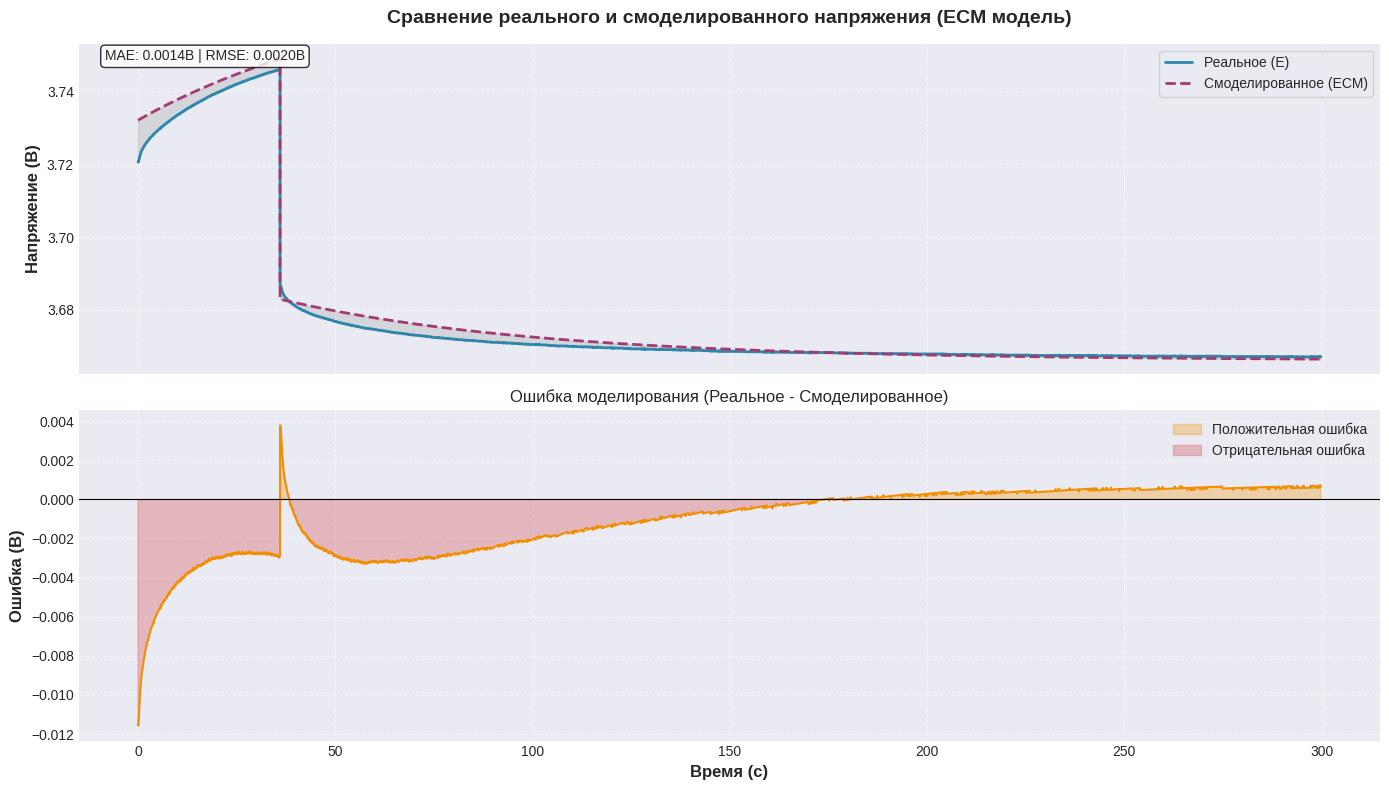

In [188]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plt.style.use('seaborn-v0_8-darkgrid')

ax1.plot(time, real_voltage, label='Реальное (E)', color='#2E86AB', linewidth=2)
ax1.plot(time, v_sinta, label='Смоделированное (ECM)', color='#A23B72', linewidth=2, linestyle='--')
ax1.fill_between(time, real_voltage, v_sinta, alpha=0.2, color='gray')
ax1.set_ylabel('Напряжение (В)', fontweight='semibold', fontsize=12)
ax1.set_title('Сравнение реального и смоделированного напряжения (ECM модель)',
              fontweight='bold', fontsize=14, pad=15)
ax1.legend(loc='upper right', frameon=True, fancybox=True)
ax1.grid(True, linestyle='--', alpha=0.5)

mae = np.mean(np.abs(real_voltage - v_sinta))
rmse = np.sqrt(np.mean((real_voltage - v_sinta)**2))
ax1.text(0.02, 0.95, f'MAE: {mae:.4f}В | RMSE: {rmse:.4f}В',
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

error = real_voltage - v_sinta
ax2.plot(time, error, color='#F18F01', linewidth=1.5)
ax2.fill_between(time, 0, error, alpha=0.3, color='#F18F01', where=(error>=0), label='Положительная ошибка')
ax2.fill_between(time, 0, error, alpha=0.3, color='#D64045', where=(error<0), label='Отрицательная ошибка')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Время (с)', fontweight='semibold', fontsize=12)
ax2.set_ylabel('Ошибка (В)', fontweight='semibold', fontsize=12)
ax2.set_title('Ошибка моделирования (Реальное - Смоделированное)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#####Генерация синты из нормального распределения.

In [189]:
def generate_ecm_params_from_y_train(y_train_df, y_key, n_samples=1, tau_pls=9.0, seed=None):
    param_cols = ['R0', 'R1', 'R2', 'C1', 'C2']

    mask = y_train_df['tau_pls'] == tau_pls
    group = y_train_df.loc[mask, param_cols].dropna().copy()

    ufin_val = y_key['Ufin']

    rng = np.random.default_rng(seed)

    if len(group) == 1:
        samples = np.repeat(group.to_numpy(dtype=float), n_samples, axis=0)
    else:
        mu = group.mean().to_numpy(dtype=float)
        cov = group.cov().to_numpy(dtype=float)
        samples = rng.multivariate_normal(mu, cov, size=n_samples)

    samples_df = pd.DataFrame(samples, columns=param_cols)

    samples_df['Ufin'] = ufin_val

    return samples_df.iloc[0].to_dict() if n_samples == 1 else samples_df

In [190]:
single_params = generate_ecm_params_from_y_train(
    y_train_full,
    y_train_full.loc['soc50_05Cchr_9sec.csv'],
    n_samples=2,
    tau_pls=9.0,
    seed=42
)

print("Сгенерированные параметры (один набор):")
single_params

Сгенерированные параметры (один набор):


,R0,R1,R2,C1,C2,Ufin
0,0.035916,0.015514,0.002062,2396.163826,48825.372692,3.707
1,0.036880,0.023598,0.002627,2202.699156,38007.590775,3.707


In [191]:
y_train_full.loc['soc50_05Cchr_9sec.csv']

,soc50_05Cchr_9sec.csv
R0,0.035610
R1,0.018011
R2,0.002260
tau_pls,9.000000
Ufin,3.707000
Uinit,3.705400
C1,2187.143114
C2,44250.179017


#### Создаем сетку параметров.

##### Вспомогательные функции

In [192]:
def downsample_profile(df, target_len=300):
    df = df.reset_index(drop=True).copy()

    if len(df) <= target_len:
        return df

    idx = np.linspace(0, len(df) - 1, target_len).round().astype(int)
    idx = np.clip(idx, 0, len(df) - 1)
    idx = np.unique(idx)

    if len(idx) < target_len:
        idx = np.linspace(0, len(df) - 1, target_len).astype(int)

    return df.iloc[idx].reset_index(drop=True)

In [193]:
def convert_real_split_to_dataset(X_split_data, target_len=300):
    data_dict = {}

    for key, (tau_pls, df) in X_split_data.items():
        df_cur = df[['Time', 'I', 'E']].copy()
        data_dict[key] = downsample_profile(df_cur, target_len=target_len)

    return data_dict

In [194]:
def build_augmented_train_dataset(
    X_train_data,
    y_train_full,
    y_train_targets,
    n_synth_per_real=5,
    target_len=300,
    base_seed=42
):
    rng = np.random.default_rng(base_seed)

    train_data = {}
    target_rows = []
    # 1. Добавляем train-профили
    for key, (tau_pls, df_real) in X_train_data.items():
        df_real_small = downsample_profile(df_real[['Time', 'I', 'E']].copy(), target_len=target_len)
        train_data[key] = df_real_small

        row = y_train_targets.loc[key].to_dict()
        row['key'] = key
        target_rows.append(row)

    # 2. Генерируем синтетику на основе реального тока и синтетических ECM-параметров
    for key, (tau_pls, df_real) in X_train_data.items():
        current = df_real['I'].to_numpy(dtype=float)
        time = df_real['Time'].to_numpy(dtype=float)

        dt_local = 0.1

        batch_params = generate_ecm_params_from_y_train(
            y_train_full,
            y_train_full.loc[key],
            n_samples=n_synth_per_real,
            tau_pls=tau_pls,
            seed=int(rng.integers(0, 1_000_000_000))
        )
        for j, (_, params) in enumerate(batch_params.iterrows()):
            voltage = simulate_ecm(
                current=current,
                dt=dt_local,
                R0=float(params['R0']),
                R1=float(params['R1']),
                C1=float(params['C1']),
                R2=float(params['R2']),
                C2=float(params['C2']),
                OCV=float(params['Ufin'])
            )
            syn_key = f"{key}__syn_{j}"

            syn_df = pd.DataFrame({
                'Time': time,
                'I': current,
                'E': voltage
            })

            train_data[syn_key] = downsample_profile(syn_df, target_len=target_len)

            target_rows.append({
                'key': syn_key,
                'R0': float(params['R0']),
                'R1': float(params['R1']),
                'R2': float(params['R2']),
                'C1': float(params['C1']),
                'C2': float(params['C2']),
                'OCV': float(params['Ufin'])
            })
    y_train_aug = pd.DataFrame(target_rows).set_index('key')

    return train_data, y_train_aug


##### Обработка синтетических данных

In [195]:
val_data = convert_real_split_to_dataset(X_val_data, target_len=300)

# Train расширяем: реальные + синтетические
train_data, y_train = build_augmented_train_dataset(
    X_train_data=X_train_data,
    y_train_full=y_train_full,
    y_train_targets=y_train_data,
    n_synth_per_real=10,
    target_len=300,

    base_seed=42
)

train_keys = list(train_data.keys())
val_keys = list(val_data.keys())

print(f"Train profiles: {len(train_data)}")
print(f"Val profiles: {len(val_data)}")
print(f"Train targets shape: {y_train.shape}")
print(f"Val targets shape: {y_val.shape}")

Train profiles: 550
Val profiles: 22
Train targets shape: (550, 7)
Val targets shape: (22, 6)


##### Пример

In [196]:
X_train_data_filtered = {}
for key in X_train_data:
  tau, data = X_train_data[key]
  if (tau <= 36):
    X_train_data_filtered[key] = [tau, data]


In [197]:
X_train_data_filtered.keys()

dict_keys(['soc45_05Cchr_36sec.csv', 'soc45_05Cchr_9sec.csv', 'soc45_05Cdch_18sec.csv', 'soc45_05Cdch_9sec.csv', 'soc45_1Cchr_18sec.csv', 'soc45_1Cchr_36sec.csv', 'soc45_1Cchr_9sec.csv', 'soc45_1Cdch_18sec.csv', 'soc45_1Cdch_9sec.csv', 'soc45_2Cchr_18sec.csv', 'soc45_2Cchr_9sec.csv', 'soc45_2Cdch_18sec.csv', 'soc45_2Cdch_9sec.csv', 'soc50_05Cchr_18sec.csv', 'soc50_05Cchr_36sec.csv', 'soc50_05Cchr_9sec.csv', 'soc50_05Cdch_18sec.csv', 'soc50_05Cdch_36sec.csv', 'soc50_05Cdch_9sec.csv', 'soc50_1Cdch_18sec.csv', 'soc50_1Cdch_36sec.csv', 'soc50_1Cdch_9sec.csv', 'soc50_2Cchr_9sec.csv', 'soc50_2Cdch_9sec.csv', 'soc50_3Cdch_9sec.csv', 'soc55_05Cchr_18sec.csv', 'soc55_05Cchr_9sec.csv', 'soc55_05Cdch_18sec.csv', 'soc55_05Cdch_36sec.csv', 'soc55_05Cdch_9sec.csv', 'soc55_1Cchr_18sec.csv', 'soc55_1Cchr_36sec.csv', 'soc55_1Cchr_9sec.csv', 'soc55_1Cdch_18sec.csv', 'soc55_1Cdch_36sec.csv', 'soc55_2Cchr_18sec.csv', 'soc55_2Cdch_9sec.csv', 'soc55_3Cchr_9sec.csv'])

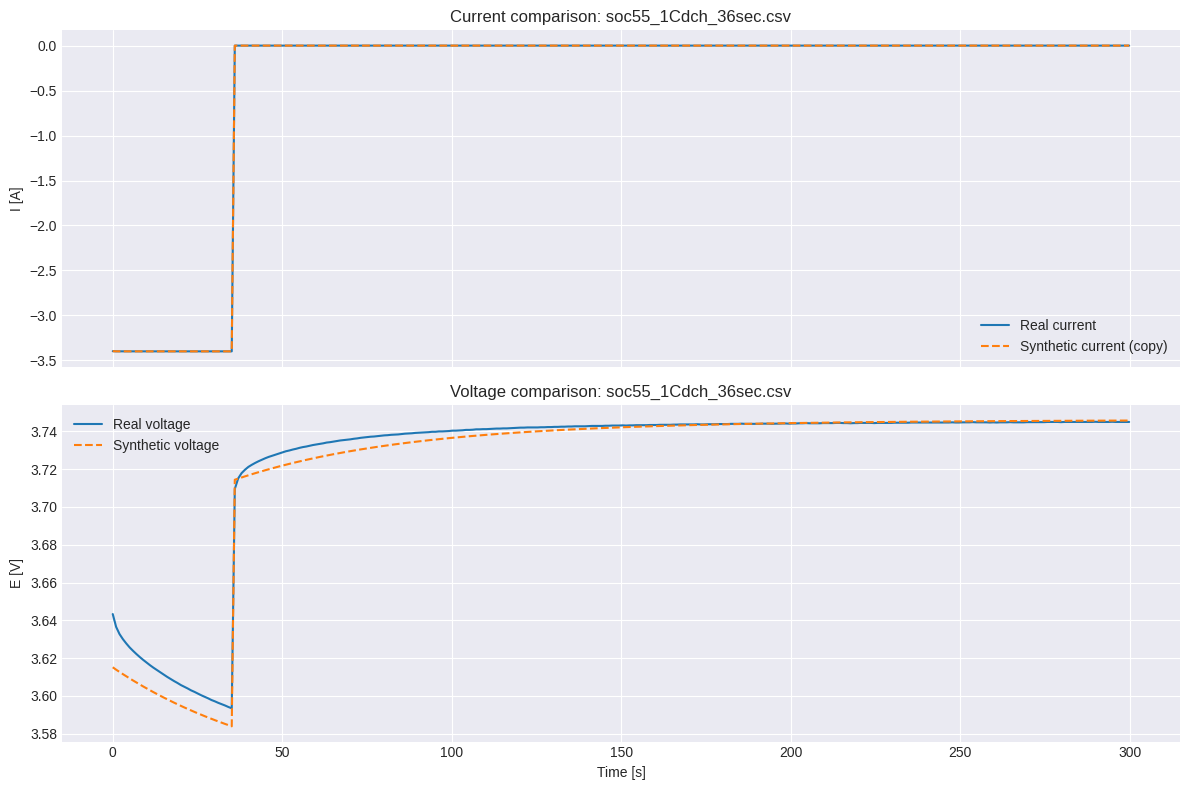

In [198]:
real_key = "soc55_1Cdch_36sec.csv"
syn_key = f'{real_key}__syn_0'

real_df = train_data[real_key]
syn_df = train_data[syn_key]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(real_df['Time'], real_df['I'], label='Real current')
axes[0].plot(syn_df['Time'], syn_df['I'], '--', label='Synthetic current (copy)')
axes[0].set_title(f'Current comparison: {real_key}')
axes[0].set_ylabel('I [A]')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(real_df['Time'], real_df['E'], label='Real voltage')
axes[1].plot(syn_df['Time'], syn_df['E'], '--', label='Synthetic voltage')
axes[1].set_title(f'Voltage comparison: {real_key}')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('E [V]')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [199]:
difference = pd.DataFrame({'real': y_train_full.loc[real_key], 'synth': y_train.loc[syn_key]})
difference['diff'] = difference['real'] - difference['synth']
difference

,real,synth,diff
C1,3194.577013,3179.816058,14.760955
C2,23851.175928,21734.379836,2116.796092
OCV,NaN,3.746200,NaN
R0,0.037729,0.038545,-0.000816
R1,0.013516,0.015057,-0.001541
R2,0.004193,0.004630,-0.000437
Ufin,3.746200,NaN,NaN
Uinit,3.760200,NaN,NaN
tau_pls,36.000000,NaN,NaN


In [200]:
def plot_density_comparison(
    y_real,
    y_synth,
    params=['R0', 'R1', 'R2', 'C1', 'C2'],
    figsize=(15, 10),
):
    """
    Построение плотности распределения реальных и синтетических параметров.

    Параметры:
    ----------
    y_real : pd.DataFrame
        DataFrame с реальными параметрами (индекс - ключи, столбцы - параметры)
    y_synth : pd.DataFrame
        DataFrame с синтетическими параметрами (та же структура)
    params : list
        Список параметров для визуализации
    figsize : tuple
        Размер фигуры
    """
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for idx, param in enumerate(params):
        ax = axes[idx]

        # Реальные данные
        if param in y_real.columns:
            sns.kdeplot(
                data=y_real[param].dropna(),
                label='Real',
                color='blue',
                fill=True,
                alpha=0.3,
                ax=ax
            )

        # Синтетические данные
        if param in y_synth.columns:
            sns.kdeplot(
                data=y_synth[param].dropna(),
                label='Synthetic',
                color='red',
                fill=True,
                alpha=0.3,
                ax=ax
            )

        ax.set_title(f'{param} distribution', fontsize=12)
        ax.set_xlabel(param)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    if len(params) < 6:
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

In [201]:
def compare_distributions_stats(y_real, y_synth, params=['R0', 'R1', 'R2', 'C1', 'C2']):
    stats = []

    for param in params:
        if param not in y_real.columns or param not in y_synth.columns:
            continue

        real_mean = y_real[param].mean()
        synth_mean = y_synth[param].mean()
        real_std = y_real[param].std()
        synth_std = y_synth[param].std()

        diff_mean = abs(real_mean - synth_mean) / abs(real_mean) * 100 if real_mean != 0 else 0

        stats.append({
            'param': param,
            'real_mean': real_mean,
            'synth_mean': synth_mean,
            'real_std': real_std,
            'synth_std': synth_std,
            'diff_percent': diff_mean
        })

    plot_density_comparison(y_real, y_synth, params)
    return pd.DataFrame(stats)

In [202]:
real_keys = [k for k in y_train.index if '__syn_' not in k]
synth_keys = [k for k in y_train.index if '__syn_' in k]

y_real = y_train.loc[real_keys]
y_synth = y_train.loc[synth_keys]

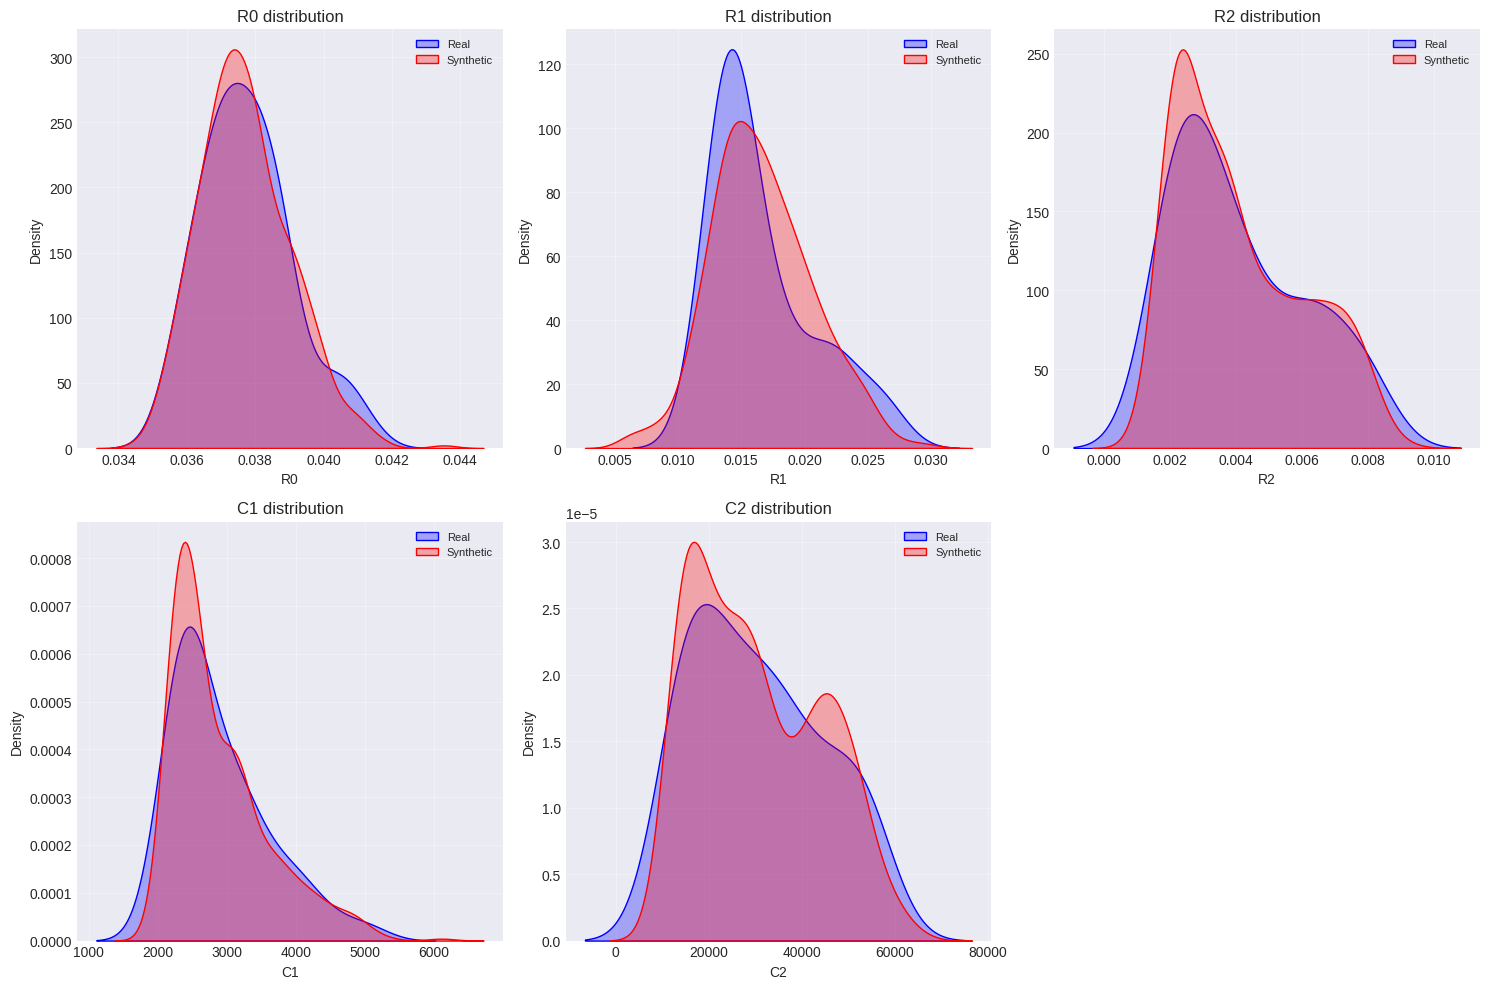

In [203]:
stats_df = compare_distributions_stats(y_real, y_synth)

## Нормировка (Собирание статистик по все train)

In [208]:
feature_cols = ['I', 'E']
target_cols = ['R0', 'R1', 'R2', 'C1', 'C2']

train_keys = [key for key in train_keys if key in train_data and key in y_train.index]
val_keys = [key for key in val_keys if key in val_data and key in y_val.index]

In [209]:
all_train_x = np.concatenate(
    [
        train_data[key][feature_cols].to_numpy(dtype=np.float64)
        for key in train_keys
    ],
    axis=0
)

x_mean = all_train_x.mean(axis=0)
x_std = all_train_x.std(axis=0, ddof=0)

x_std = np.where(x_std < 1e-8, 1.0, x_std)

print("X normalization stats:")
print("feature_cols:", feature_cols)
print("x_mean:", x_mean)
print("x_std :", x_std)

X normalization stats:
feature_cols: ['I', 'E']
x_mean: [0.03015134 3.71239496]
x_std : [1.0556313  0.06012747]


In [210]:
all_train_y = y_train.loc[train_keys, target_cols].to_numpy(dtype=np.float64)

y_mean = all_train_y.mean(axis=0)
y_std = all_train_y.std(axis=0, ddof=0)

y_std = np.where(y_std < 1e-8, 1.0, y_std)

print("\nY normalization stats:")
print("target_cols:", target_cols)
print("y_mean:", y_mean)
print("y_std :", y_std)


Y normalization stats:
target_cols: ['R0', 'R1', 'R2', 'C1', 'C2']
y_mean: [3.77163984e-02 1.66305590e-02 4.07834346e-03 2.88622885e+03
 3.03440505e+04]
y_std : [1.33373941e-03 3.98451316e-03 1.91492012e-03 7.00907394e+02
 1.35137122e+04]


In [211]:
x_mean_s = pd.Series(x_mean, index=feature_cols, name='x_mean')
x_std_s  = pd.Series(x_std,  index=feature_cols, name='x_std')

y_mean_s = pd.Series(y_mean, index=target_cols, name='y_mean')
y_std_s  = pd.Series(y_std,  index=target_cols, name='y_std')

display(x_mean_s)
display(x_std_s)
display(y_mean_s)
display(y_std_s)

,x_mean
I,0.030151
E,3.712395


,x_std
I,1.055631
E,0.060127


,y_mean
R0,0.037716
R1,0.016631
R2,0.004078
C1,2886.228852
C2,30344.050484


,y_std
R0,0.001334
R1,0.003985
R2,0.001915
C1,700.907394
C2,13513.712164


## Dataset

In [243]:
class ECMDataset(Dataset):
    def __init__(self, data_dict, target_dict, keys, x_mean, x_std, y_mean, y_std, return_key=False):
        self.return_key = return_key
        self.keys = [key for key in keys if key in data_dict and key in target_dict.index]
        self.params = ['R0', 'R1', 'R2', 'C1', 'C2']

        if not self.keys:
            raise ValueError("После фильтрации не осталось ни одного корректного key.")

        # Статистики
        self.x_mean = np.asarray(x_mean, dtype=np.float32)
        self.x_std  = np.where(np.asarray(x_std, dtype=np.float32) < 1e-8, 1.0, np.asarray(x_std, dtype=np.float32))
        self.y_mean = np.asarray(y_mean, dtype=np.float32)
        self.y_std  = np.where(np.asarray(y_std, dtype=np.float32) < 1e-8, 1.0, np.asarray(y_std, dtype=np.float32))

        data_list, target_list, ocv_list = [], [], []
        expected_len = None

        for key in self.keys:
            df = data_dict[key]
            x = df[['I', 'E']].to_numpy(dtype=np.float32)

            if expected_len is None:
                expected_len = x.shape[0]
            elif x.shape[0] != expected_len:
                raise ValueError(f"У профиля {key} длина {x.shape[0]}, ожидалась {expected_len}.")

            # Нормировка X
            x = (x - self.x_mean) / self.x_std
            data_list.append(x)

            # Таргеты
            y_raw = target_dict.loc[key][self.params].to_numpy(dtype=np.float32)
            y = (y_raw - self.y_mean) / self.y_std
            target_list.append(y)

            # OCV (отдельно)
            ocv_val = target_dict.loc[key]['OCV']

            ocv_list.append(np.array(ocv_val, dtype=np.float32))

        self.data_arrays = np.stack(data_list, axis=0).astype(np.float32)
        self.target_arrays = np.stack(target_list, axis=0).astype(np.float32)
        self.ocv_arrays = np.array(ocv_list, dtype=np.float32)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.data_arrays[idx])
        y = torch.from_numpy(self.target_arrays[idx])
        ocv = torch.from_numpy(np.array([self.ocv_arrays[idx]])) # Добавляем размерность для консистентности

        if self.return_key:
            return x, y, self.keys[idx]

        return x, y, ocv

## Подготовка данных: Dataset -> Dataloader

In [244]:
y_val = y_val.rename(columns = {'Ufin': 'OCV'})
y_val.head(3)

,R0,R1,R2,C1,C2,OCV
table_file,,,,,,
soc45_05Cchr_18sec.csv,0.038244,0.020053,0.003791,2541.781301,26378.039851,3.6656
soc45_05Cdch_144sec.csv,0.041387,0.024470,0.012494,5041.127631,8003.795124,3.6510
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,3307.338185,14533.132864,3.6611


In [245]:
# y_train['OCV'] = y_train['OCV'].fillna(y_train['Ufin'])
# y_train = y_train.drop('Ufin', axis=1)
y_train.head(3)

,R0,R1,R2,C1,C2,OCV
key,,,,,,
soc45_05Cchr_144sec.csv,0.040510,0.014111,0.007961,4618.113097,12560.928487,3.6674
soc45_05Cchr_36sec.csv,0.038822,0.018847,0.005238,3282.074009,19092.912205,3.6661
soc45_05Cchr_72sec.csv,0.039922,0.015928,0.006489,4013.631904,15410.643506,3.6666


In [246]:
train_dataset = ECMDataset(
    data_dict=train_data,
    target_dict=y_train,
    keys=train_keys,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std,
    return_key=False
)

val_dataset = ECMDataset(
    data_dict=val_data,
    target_dict=y_val,
    keys=val_keys,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std,
    return_key=False
)

print("len(train_dataset) =", len(train_dataset))
print("len(val_dataset)   =", len(val_dataset))

x0, y0, ocv0 = train_dataset[0]
print("One sample x shape:", x0.shape)   # [T, 2]
print("One sample y shape:", y0.shape)   # [5]

len(train_dataset) = 550
len(val_dataset)   = 22
One sample x shape: torch.Size([300, 2])
One sample y shape: torch.Size([5])


In [247]:
y0

tensor([ 2.0948, -0.6322,  2.0277,  2.4709, -1.3159])

In [248]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [249]:
x_batch, y_batch, ocv = next(iter(train_loader))

print("x_batch.shape =", x_batch.shape)   # [B, T, 2]
print("y_batch.shape =", y_batch.shape)   # [B, 5]

x_batch.shape = torch.Size([16, 300, 2])
y_batch.shape = torch.Size([16, 5])


## Модель на основе 1D-CNN

In [250]:
class D1_CNN(nn.Module):
    def __init__(self, input_size=1, out_size=5, hiden_size=32, dropout=0.15):
        super().__init__()

        h = hiden_size

        self.features = nn.Sequential(
            nn.Conv1d(input_size, h, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(h),
            nn.SiLU(),

            nn.Conv1d(h, h * 2, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(h * 2),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Conv1d(h * 2, h * 4, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(h * 4),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Conv1d(h * 4, h * 8, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(h * 8),
            nn.SiLU(),

            nn.Conv1d(h * 8, h * 8, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm1d(h * 8),
            nn.SiLU(),
            nn.Dropout(dropout),
        )

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        self.head = nn.Sequential(
            nn.Linear(h * 16, h * 8),
            nn.LayerNorm(h * 8),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(h * 8, out_size)
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, a=math.sqrt(5))
            if m.bias is not None:
                fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
                nn.init.uniform_(m.bias, -bound, bound)
        elif isinstance(m, (nn.BatchNorm1d, nn.LayerNorm)):
            if m.weight is not None:
                nn.init.ones_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x, mask=None):
        x = x.transpose(1, 2)
        x = self.features(x)

        x_avg = self.avg_pool(x).squeeze(-1)
        x_max = self.max_pool(x).squeeze(-1)

        x = torch.cat([x_avg, x_max], dim=1)
        x = self.head(x)
        return x

## Обучение

Инициализация.

In [273]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = D1_CNN(input_size=2, out_size=5, hiden_size=64, dropout=0.15).to(device)

criterion = nn.SmoothL1Loss(beta=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

Лосс, оптимизатор, скедулер.

In [274]:
criterion = nn.SmoothL1Loss(beta=0.1)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
    betas=(0.9, 0.999),
    eps=1e-8
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

### Функции для обучения.

inverse_transform

In [275]:
def denormalize_targets(y, y_mean, y_std, device=None):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float32, device=device)

    y_mean_t = torch.as_tensor(y_mean, dtype=y.dtype, device=y.device)
    y_std_t = torch.as_tensor(y_std, dtype=y.dtype, device=y.device)

    return y * y_std_t + y_mean_t

Обучение 1 эпохи.

In [276]:
def unpack_batch(batch, device):
    """
    Распаковывает батч из DataLoader.

    Поддерживает два формата:
    1. (x, y) - без маски
    2. (x, y, mask) - с маской
    """
    if len(batch) == 3:
        x_batch, y_batch, ocv_batch = batch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        ocv_batch = ocv_batch.to(device)
        return x_batch, y_batch, ocv_batch
    else:
        x_batch, y_batch = batch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        return x_batch, y_batch, None

In [277]:
def calculate_mape_torch(y_true, y_pred, eps=1e-8):
    """
    Вычисляет MAPE (Mean Absolute Percentage Error) для тензоров PyTorch.

    Параметры:
    ----------
    y_true : torch.Tensor
        Истинные значения, форма [N, D]
    y_pred : torch.Tensor
        Предсказанные значения, форма [N, D]
    eps : float
        Малое число для избежания деления на ноль

    Возвращает:
    ----------
    mape_mean : float
        Средний MAPE по всем параметрам
    mape_per_dim : np.ndarray
        MAPE по каждому параметру отдельно
    """
    denom = torch.clamp(torch.abs(y_true), min=eps)
    mape_per_dim = torch.mean(torch.abs((y_true - y_pred) / denom), dim=0) * 100.0
    mape_mean = torch.mean(mape_per_dim)

    return mape_mean.item(), mape_per_dim.detach().cpu().numpy()

In [281]:
def simulate_ecm_torch(current, dt, R0, R1, C1, R2, C2, OCV):
    v1, v2 = 0.0, 0.0
    v_terminal = torch.zeros_like(current)
    current = -current

    # Защита от деления на ноль
    tau1 = torch.clamp(R1 * C1, min=1e-6)
    tau2 = torch.clamp(R2 * C2, min=1e-6)

    a1 = torch.exp(-dt / tau1)
    a2 = torch.exp(-dt / tau2)

    # Clamp a1, a2 чтобы не было inf
    a1 = torch.clamp(a1, min=0.0, max=1.0)
    a2 = torch.clamp(a2, min=0.0, max=1.0)

    for i in range(len(current)):
        v1 = a1 * v1 + R1 * (1 - a1) * current[i]
        v2 = a2 * v2 + R2 * (1 - a2) * current[i]
        v_terminal[i] = OCV - current[i] * R0 - v1 - v2

    return v_terminal


def train_one_epoch(model, loader, criterion, optimizer, device, y_mean, y_std, x_mean, x_std, grad_clip=1.0):
    """
    x_mean, x_std — статистики для нормировки напряжения (E находится во 2-й колонке X).
    """
    model.train()
    running_loss = 0.0
    preds_denorm, targets_denorm = [], []

    pbar = tqdm(loader, desc="Train", leave=False)

    # Статистики для напряжения (E — 2-й признак, индекс 1)
    v_mean = x_mean[1]
    v_std = max(x_std[1], 1e-8)

    for batch in pbar:
        x_batch, y_batch, ocv_batch = unpack_batch(batch, device)  # x: [B, T, 2]
        batch_size = x_batch.shape[0]

        optimizer.zero_grad(set_to_none=True)

        output = model(x_batch)  # [B, 5]

        # Денормализация параметров
        y_pred_denorm = denormalize_targets(output, y_mean, y_std)  # [B, 5]
        y_true_denorm = denormalize_targets(y_batch, y_mean, y_std)

        # Симуляция (возвращает напряжение в оригинальной шкале)
        simulated_voltages = []
        for b in range(batch_size):
            current = x_batch[b, :, 0]  # [T]
            params = y_pred_denorm[b]   # [5]
            ocv = ocv_batch[b]

            v_sim = simulate_ecm_torch(
                current, dt=0.1,
                R0=params[0], R1=params[1], C1=params[2],
                R2=params[3], C2=params[4], OCV=ocv
            )
            simulated_voltages.append(v_sim)

        simulated_voltage = torch.stack(simulated_voltages)  # [B, T]

        # === НОРМИРОВКА симулированного напряжения ===
        simulated_voltage_norm = (simulated_voltage - v_mean) / v_std

        # Target voltage (уже нормирован в датасете)
        target_voltage_norm = x_batch[:, :, 1]  # [B, T]

        # Loss
        loss = criterion(simulated_voltage_norm, target_voltage_norm)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()

        running_loss += loss.item() * batch_size

        preds_denorm.append(y_pred_denorm.detach().cpu())
        targets_denorm.append(y_true_denorm.detach().cpu())

        pbar.set_postfix(loss=f"{running_loss / (len(preds_denorm) * batch_size):.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    y_true_epoch = torch.cat(targets_denorm, dim=0)
    y_pred_epoch = torch.cat(preds_denorm, dim=0)

    epoch_mape, epoch_mape_per_dim = calculate_mape_torch(y_true_epoch, y_pred_epoch)

    return epoch_loss, epoch_mape, epoch_mape_per_dim

Валидация.

In [282]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, y_mean, y_std, desc="Eval"):
    model.eval()

    running_loss = 0.0
    preds_denorm = []
    targets_denorm = []

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        x_batch, y_batch, mask_batch = unpack_batch(batch, device)

        if mask_batch is None:
            output = model(x_batch)
        else:
            output = model(x_batch, mask_batch)

        loss = criterion(output, y_batch)
        running_loss += loss.item()

        y_pred_denorm = denormalize_targets(output, y_mean, y_std)
        y_true_denorm = denormalize_targets(y_batch, y_mean, y_std)

        preds_denorm.append(y_pred_denorm.cpu())
        targets_denorm.append(y_true_denorm.cpu())

        pbar.set_postfix(loss=f"{running_loss / (len(preds_denorm)):.4f}")

    epoch_loss = running_loss / len(loader)

    y_true_epoch = torch.cat(targets_denorm, dim=0)
    y_pred_epoch = torch.cat(preds_denorm, dim=0)

    epoch_mape, epoch_mape_per_dim = calculate_mape_torch(y_true_epoch, y_pred_epoch)

    return epoch_loss, epoch_mape, epoch_mape_per_dim, y_true_epoch, y_pred_epoch

### Обучение

In [283]:
num_epochs = 15
patience = 3

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mape": [],
    "val_mape": [],
    "lr": []
}

best_val_loss = float("inf")
best_epoch = -1
best_state = copy.deepcopy(model.state_dict())
epochs_without_improve = 0

for epoch in range(num_epochs):
    train_loss, train_mape, train_mape_per_dim = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        y_mean=y_mean,
        y_std=y_std,
        x_mean = x_mean,
        x_std = x_std,
        grad_clip=1.0
    )

    val_loss, val_mape, val_mape_per_dim, y_true_val, y_pred_val = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        y_mean=y_mean,
        y_std=y_std,
        desc="Validation"
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mape"].append(train_mape)
    history["val_mape"].append(val_mape)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch + 1:03d}/{num_epochs} | "
        f"train_loss={train_loss:.5f} | "
        f"val_loss={val_loss:.5f} | "
        f"train_mape={train_mape:.3f}% | "
        f"val_mape={val_mape:.3f}% | "
        f"lr={current_lr:.2e}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, "best_d1_cnn_model.pth")
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

model.load_state_dict(best_state)

print(f"\nBest epoch: {best_epoch}")
print(f"Best val_loss: {best_val_loss:.5f}")

KeyboardInterrupt: 

Графики

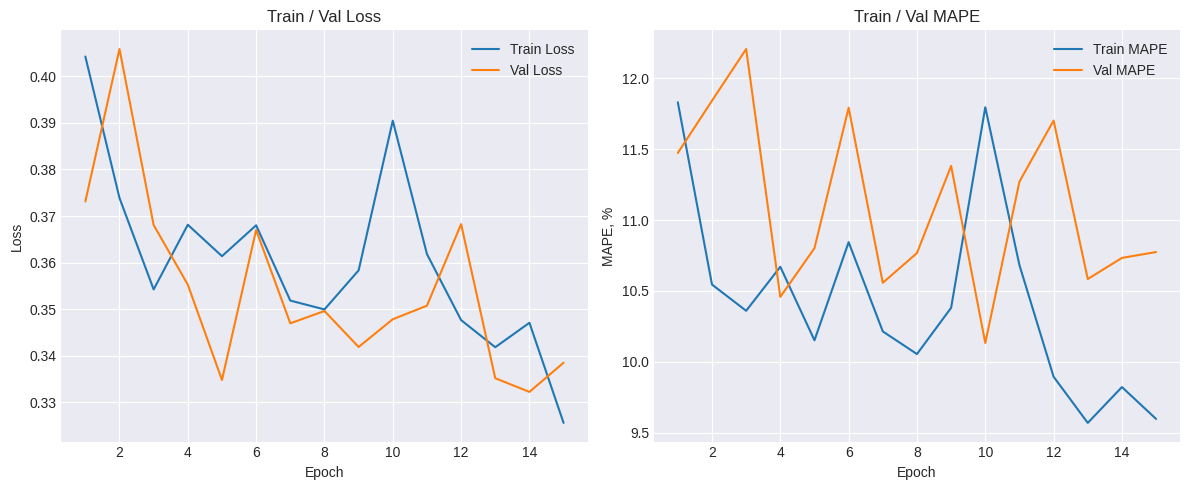

In [266]:
epochs_range = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_mape"], label="Train MAPE")
plt.plot(epochs_range, history["val_mape"], label="Val MAPE")
plt.xlabel("Epoch")
plt.ylabel("MAPE, %")
plt.title("Train / Val MAPE")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Предсказания.

#### Функции для получения предсказаний.

MAPE

In [267]:
def calculate_mape(y_true, y_pred, eps=1e-8):
    denom = torch.clamp(torch.abs(y_true), min=eps)
    mape_per_dim = torch.mean(torch.abs((y_true - y_pred) / denom), dim=0) * 100.0
    mape_mean = torch.mean(mape_per_dim)
    return mape_mean.item(), mape_per_dim.detach().cpu().numpy()

Обработчик батчей

In [268]:
def unpack_batch(batch, device):
    if len(batch) == 3:
        x_batch, y_batch, mask_batch = batch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        return x_batch, y_batch, mask_batch
    else:
        x_batch, y_batch = batch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        return x_batch, y_batch, None

Тестирование модели.

In [269]:
def test_model(model, test_loader, device):
    model.eval()

    all_y_true = []
    all_y_pred = []

    test_loss = 0.0

    with torch.no_grad():
        test_pbar = tqdm(test_loader, desc="Testing")

        for batch in test_pbar:
            if len(batch) == 3:
                x_batch, y_batch, mask_batch = batch
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                mask_batch = mask_batch.to(device)

                output = model(x_batch, mask_batch)
            else:
                x_batch, y_batch = batch
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                output = model(x_batch)

            loss = criterion(output, y_batch)
            test_loss += loss.item()

            all_y_true.append(y_batch.cpu())
            all_y_pred.append(output.cpu())

            test_pbar.set_postfix({"test_loss": f"{loss.item():.4f}"})

    test_loss /= len(test_loader)

    y_true = torch.cat(all_y_true, dim=0) * y_std + y_mean
    y_pred = torch.cat(all_y_pred, dim=0) * y_std + y_mean

    mape = calculate_mape(y_true, y_pred)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"MAPE: {100*mape}%")

    return y_true, y_pred, mape

Получение предсказания.

In [270]:
def predict(model, data_loader, device):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting"):
            if len(batch) == 3:
                x_batch, y_batch, mask_batch = batch
                x_batch = x_batch.to(device)
                mask_batch = mask_batch.to(device)

                output = model(x_batch, mask_batch)
            else:
                x_batch, y_batch = batch
                x_batch = x_batch.to(device)

                output = model(x_batch)

            all_predictions.append(output.cpu())
            all_targets.append(y_batch.cpu())

    predictions = torch.cat(all_predictions, dim=0).numpy()
    targets = torch.cat(all_targets, dim=0).numpy()

    return predictions, targets

In [271]:
@torch.no_grad()
def test_model(model, test_loader, criterion, device, y_mean, y_std, target_cols=None):
    test_loss, test_mape, test_mape_per_dim, y_true, y_pred = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device,
        y_mean=y_mean,
        y_std=y_std,
        desc="Testing"
    )

    print(f"Test Loss: {test_loss:.5f}")
    print(f"Test MAPE: {test_mape:.3f}%")

    if target_cols is not None:
        print("\nMAPE by parameter:")
        for name, value in zip(target_cols, test_mape_per_dim):
            print(f"{name}: {value:.3f}%")

    return {
        "test_loss": test_loss,
        "test_mape": test_mape,
        "test_mape_per_dim": test_mape_per_dim,
        "y_true": y_true,
        "y_pred": y_pred
    }

#### Итоговые предсказания.

In [272]:
target_cols = ['R0', 'R1', 'R2', 'C1', 'C2']

results = test_model(
    model=model,
    test_loader=val_loader,
    criterion=criterion,
    device=device,
    y_mean=y_mean,
    y_std=y_std,
    target_cols=target_cols
)

y_true = results["y_true"]
y_pred = results["y_pred"]
mape = results["test_mape"]

Test Loss: 0.33221
Test MAPE: 10.733%

MAPE by parameter:
R0: 1.603%
R1: 16.601%
R2: 14.592%
C1: 5.682%
C2: 15.187%


In [273]:
y_true[:3]

tensor([[3.8244e-02, 2.0053e-02, 3.7910e-03, 2.5418e+03, 2.6378e+04],
        [4.1387e-02, 2.4470e-02, 1.2494e-02, 5.0411e+03, 8.0038e+03],
        [3.9573e-02, 2.9765e-02, 6.8808e-03, 3.3073e+03, 1.4533e+04]])

In [274]:
y_pred[:3]

tensor([[3.7322e-02, 1.7074e-02, 3.4409e-03, 2.5645e+03, 3.0323e+04],
        [4.0501e-02, 1.4916e-02, 8.0197e-03, 4.5527e+03, 1.2933e+04],
        [3.8571e-02, 1.7060e-02, 5.1789e-03, 3.0793e+03, 1.9406e+04]])

In [275]:
def create_comparison_df(y_true, y_pred, target_cols):
    """
    Создаёт DataFrame для сравнения истинных и предсказанных значений.

    Параметры:
    ----------
    y_true : torch.Tensor или np.ndarray
        Истинные значения, форма [N, D]
    y_pred : torch.Tensor или np.ndarray
        Предсказанные значения, форма [N, D]
    target_cols : list
        Список названий целевых параметров

    Возвращает:
    ----------
    df_compare : pd.DataFrame
        DataFrame с колонками true_{col} и pred_{col} для каждого параметра
    """
    # Конвертация в numpy если нужно
    if torch.is_tensor(y_true):
        y_true = y_true.cpu().numpy()
    if torch.is_tensor(y_pred):
        y_pred = y_pred.cpu().numpy()

    # Создание словаря для DataFrame
    data = {}
    for i, col in enumerate(target_cols):
        data[f'true_{col}'] = y_true[:, i]
        data[f'pred_{col}'] = y_pred[:, i]

    df_compare = pd.DataFrame(data)
    return df_compare


def calculate_metrics_summary(df_compare, target_cols):
    """
    Вычисляет метрики качества для каждого параметра.

    Параметры:
    ----------
    df_compare : pd.DataFrame
        DataFrame с колонками true_{col} и pred_{col}
    target_cols : list
        Список названий целевых параметров

    Возвращает:
    ----------
    df_summary : pd.DataFrame
        DataFrame с метриками по каждому параметру
    """
    summary_rows = []

    for col in target_cols:
        true_col = df_compare[f'true_{col}'].to_numpy()
        pred_col = df_compare[f'pred_{col}'].to_numpy()

        abs_err = np.abs(pred_col - true_col)
        sq_err = (pred_col - true_col) ** 2
        ape = abs_err / np.clip(np.abs(true_col), 1e-8, None) * 100.0

        summary_rows.append({
            'parameter': col,
            'true_mean': np.mean(true_col),
            'pred_mean': np.mean(pred_col),
            'true_std': np.std(true_col),
            'pred_std': np.std(pred_col),
            'MSE': np.mean(sq_err),
            'MAE': np.mean(abs_err),
            'MAPE': np.mean(ape),
        })

    df_summary = pd.DataFrame(summary_rows)
    return df_summary


def plot_predictions_scatter(df_compare, target_cols, figsize=(15, 10)):
    """
    Строит графики scatter для сравнения предсказаний с истинными значениями.

    Параметры:
    ----------
    df_compare : pd.DataFrame
        DataFrame с колонками true_{col} и pred_{col}
    target_cols : list
        Список названий целевых параметров
    figsize : tuple
        Размер фигуры
    """
    n_params = len(target_cols)
    n_cols = min(3, n_params)
    n_rows = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_params > 1 else [axes]

    for idx, col in enumerate(target_cols):
        ax = axes[idx]
        true_vals = df_compare[f'true_{col}'].values
        pred_vals = df_compare[f'pred_{col}'].values

        ax.scatter(true_vals, pred_vals, alpha=0.5, s=10)

        # Линия y=x
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')

        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{col}')
        ax.grid(alpha=0.3)
        ax.legend()

    # Скрыть неиспользуемые подграфики
    for idx in range(len(target_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()


def plot_residuals(df_compare, target_cols, figsize=(15, 8)):
    """
    Строит графики остатков (pred - true) для каждого параметра.

    Параметры:
    ----------
    df_compare : pd.DataFrame
        DataFrame с колонками true_{col} и pred_{col}
    target_cols : list
        Список названий целевых параметров
    figsize : tuple
        Размер фигуры
    """
    n_params = len(target_cols)
    n_cols = min(3, n_params)
    n_rows = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_params > 1 else [axes]

    for idx, col in enumerate(target_cols):
        ax = axes[idx]
        true_vals = df_compare[f'true_{col}'].values
        pred_vals = df_compare[f'pred_{col}'].values
        residuals = pred_vals - true_vals

        ax.scatter(true_vals, residuals, alpha=0.5, s=10)
        ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)

        ax.set_xlabel('True')
        ax.set_ylabel('Residual (pred - true)')
        ax.set_title(f'{col}')
        ax.grid(alpha=0.3)

    for idx in range(len(target_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

,parameter,true_mean,pred_mean,true_std,pred_std,MSE,MAE,MAPE
0,R0,0.037866,0.037918,0.001474,0.001190,5.786747e-07,0.000611,1.603443
1,R1,0.016490,0.015478,0.004730,0.000980,2.117068e-05,0.003122,16.600807
2,R2,0.004624,0.004332,0.002958,0.002045,1.817221e-06,0.000829,14.592130
3,C1,3032.799316,2950.950195,765.470398,763.820984,6.809482e+04,191.673828,5.682071
4,C2,30413.117188,29923.123047,15600.510742,14516.651367,1.306303e+07,3148.772461,15.186830


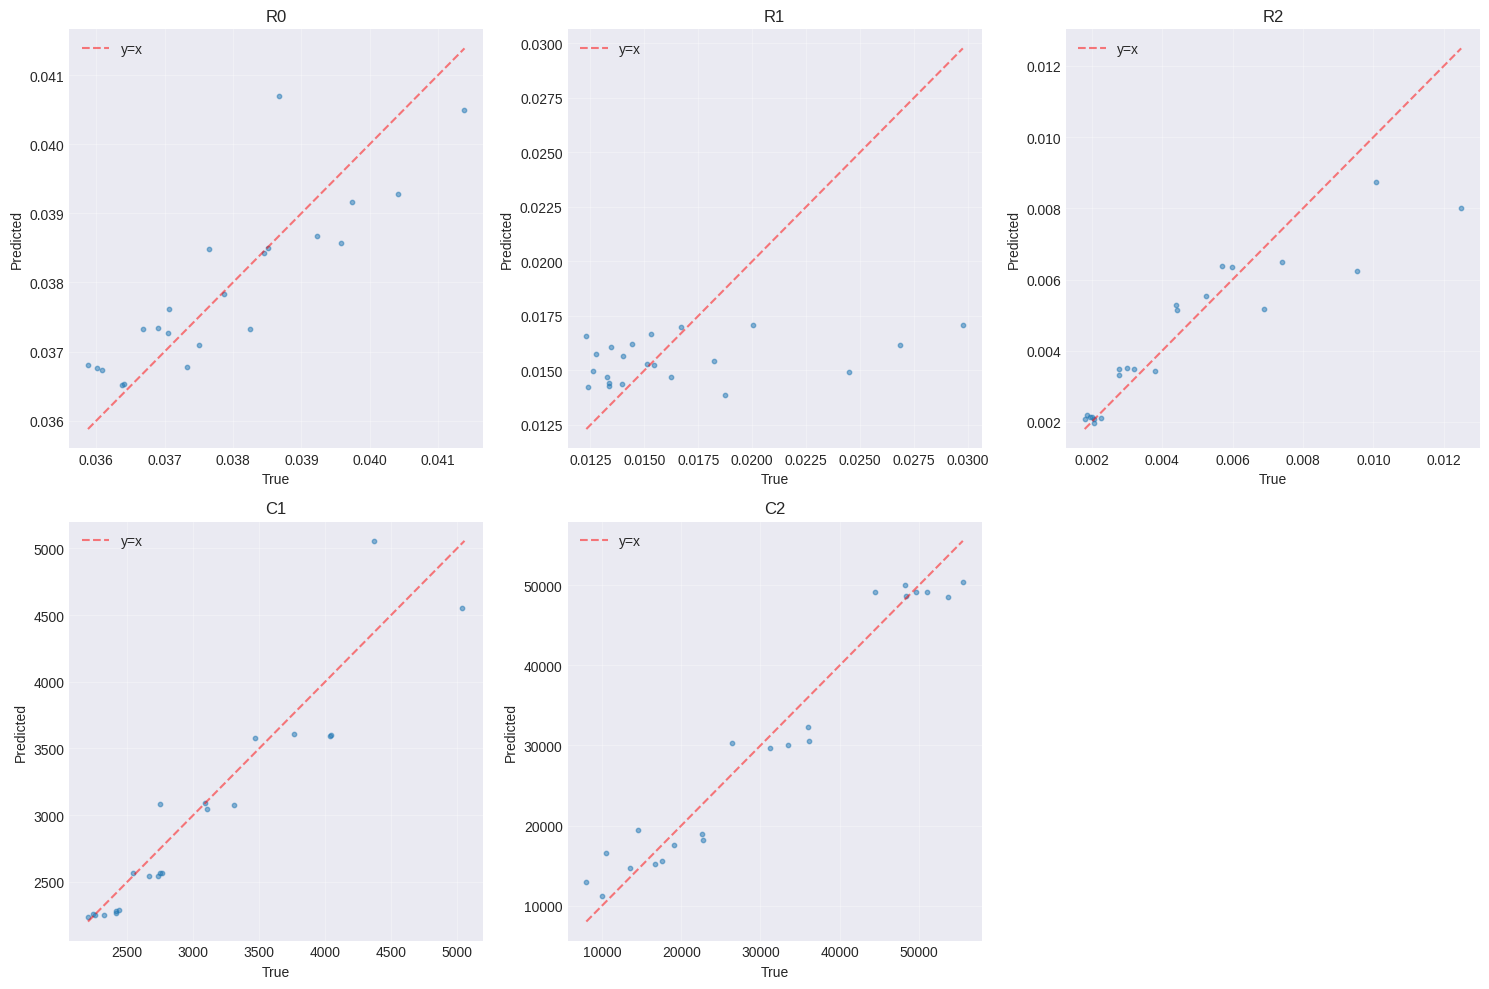

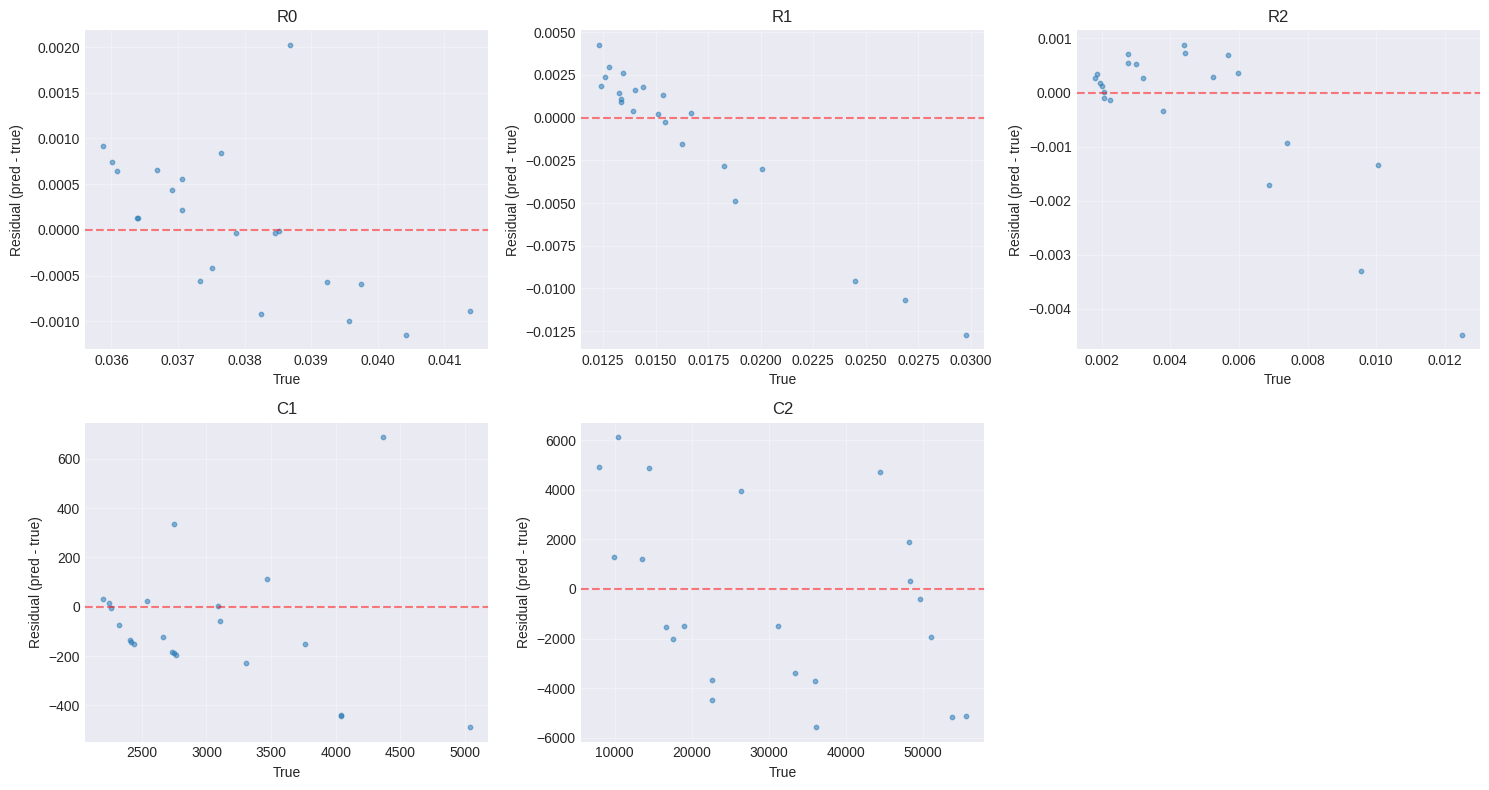

In [276]:
# Создание DataFrame для сравнения
df_compare = create_comparison_df(y_true, y_pred, target_cols)

# Расчёт метрик
df_summary = calculate_metrics_summary(df_compare, target_cols)
display(df_summary)

# Визуализация
plot_predictions_scatter(df_compare, target_cols)
plot_residuals(df_compare, target_cols)